# Resultados: cálculo de los reguladores, simulaciones y análisis de ruido
**Proyecto Integrador Profesional — Agustín Schwerdt**

Este cuaderno reúne los cálculos que respaldan los Capítulos 3 y 4 del PIP:

1. Modelo discreto de los cuatro subsistemas (§3.3.2 y §3.3.4).
2. Solución de la DARE y ganancias de los reguladores LQR (§3.3.5, Tabla 3.6).
3. Ganancias de Kalman con las covarianzas R asumidas (§3.3.6; Tabla 4.3, filas asumidas).
4. Simulación del lazo cerrado (§3.3.7, Figura 3.5).
5. Ruido medido de los sensores y ajuste de R (§4.2, Figura 4.2 y Tabla 4.2).
6. Ganancias de Kalman con las R ajustadas (§4.2; Tabla 4.3, filas ajustadas).
7. Simulación del observador: R asumidas frente a R ajustadas (§4.2, Figura 4.3).
8. Vuelo final con el diseño ajustado (§4.3, Figura 4.4).
9. Verificación del ruido en el vuelo final (§4.3, Figura 4.5).
10. Estados medidos frente a estimados por Kalman (§4.3, Figura 4.6).
11. Beneficio del filtro: ángulo frente a velocidad angular (§4.3, cifras del texto sobre la Figura 4.6).
12. Polos en el plano z: planta, lazo cerrado y observador (§4.4, Figura 4.7 y Tabla 4.4).

Unidades: actitud en grados y °/s, altura en m y m/s, comando en cuentas PWM.

In [1]:
import glob, re
import numpy as np
import pandas as pd
import control as ct
import matplotlib.pyplot as plt

plt.rcParams.update({"font.family": "serif", "font.size": 11,
                     "axes.grid": True, "grid.alpha": 0.5, "grid.linestyle": "--"})
np.set_printoptions(precision=4, suppress=False)

import os
VUELOS = os.path.join("..", "telemetria", "vuelos")   # registros de vuelo del repositorio


## 1. Modelo discreto

Parámetros físicos (Tabla 3.4) y constantes de entrada de cada subsistema (Ec. 42 a 54). Los tres subsistemas de segundo orden
son dobles integradores; con retención de orden cero y $h = 4$ ms:

$$\mathbf{\Phi} = \begin{bmatrix}1 & h\\ 0 & 1\end{bmatrix},\qquad
\mathbf{\Gamma} = \begin{bmatrix} b\,h^2/2 \\ b\,h\end{bmatrix}$$

In [2]:
# Parámetros físicos
m, g = 0.066, 9.80665            # masa [kg], gravedad [m/s^2]
L = 0.059752                     # distancia CG-rotor [m]
d = L / np.sqrt(2)               # brazo respecto de X_B e Y_B [m]
m_m = 0.003                      # masa de cada motor [kg]
m_b = m - 4 * m_m                # masa del cuerpo central [kg]
a = b_lado = 0.050               # lados del cuerpo central [m]
PWM_hov = 1600                   # comando de equilibrio
c_tau = 0.005964552              # relación par-empuje de la hélice [m]
h = 0.004                        # período de muestreo [s]

# Constantes derivadas
k_f = m * g / (4 * PWM_hov)                        # empuje por motor y cuenta [N]
I_xx = 2 * m_m * L**2 + m_b * b_lado**2 / 12       # [kg m^2]
I_zz = 4 * m_m * L**2 + m_b * (a**2 + b_lado**2) / 12
K_tau = 4 * d * k_f                                # [N m / cuenta]
K_kappa = 4 * c_tau * k_f                          # [N m / cuenta]
K_T = 4 * k_f                                      # [N / cuenta]

R2D = 180 / np.pi
b_att = R2D * K_tau / I_xx      # [°/s^2 por cuenta]
b_yaw = R2D * K_kappa / I_zz    # [°/s^2 por cuenta]
b_alt = K_T / m                 # [m/s^2 por cuenta]

def zoh(b):
    Phi = np.array([[1, h], [0, 1]])
    Gam = np.array([[b * h**2 / 2], [b * h]])
    return Phi, Gam

Phi, Gam_att = zoh(b_att)
_, Gam_alt = zoh(b_alt)
_, Gam_alt_kf = zoh(1.0)        # estimador de altura: entrada = aceleración
Phi_yaw, Gam_yaw = np.array([[1.0]]), np.array([[b_yaw * h]])

print(f"k_f   = {k_f:.4e} N/cuenta")
print(f"I_xx  = {I_xx:.4e} kg m^2   I_zz = {I_zz:.4e} kg m^2")
print(f"K_tau = {K_tau:.4e} N m/cuenta   K_kappa = {K_kappa:.4e} N m/cuenta")
print(f"b_att = {b_att:.4f} °/s^2   b_yaw = {b_yaw:.4f} °/s^2   b_alt = {b_alt:.4e} m/s^2  (por cuenta)")
print()
print("Gamma actitud        :", Gam_att.ravel())
print("Gamma guiñada        :", Gam_yaw.ravel())
print("Gamma altura (LQR)   :", Gam_alt.ravel())
print("Gamma altura (Kalman):", Gam_alt_kf.ravel())

k_f   = 1.0113e-04 N/cuenta
I_xx  = 3.2672e-05 kg m^2   I_zz = 6.5344e-05 kg m^2
K_tau = 1.7092e-05 N m/cuenta   K_kappa = 2.4128e-06 N m/cuenta
b_att = 29.9731 °/s^2   b_yaw = 2.1156 °/s^2   b_alt = 6.1292e-03 m/s^2  (por cuenta)

Gamma actitud        : [0.0002 0.1199]
Gamma guiñada        : [0.0085]
Gamma altura (LQR)   : [4.9033e-08 2.4517e-05]
Gamma altura (Kalman): [8.e-06 4.e-03]


## 2. Reguladores LQR: solución de la DARE

Se eligen las ponderaciones de las Ec. 60 y 61 y se resuelve la DARE con `control.dlqr`, que devuelve la
ganancia $\mathbf{L}$ y la solución $\mathbf{P}$. Las ganancias se imprimen como líneas de `Config.h`, para
copiarlas y pegarlas en el firmware sin redondeo.

In [3]:
canales = {
    "Alabeo y cabeceo": (Phi,     Gam_att, np.diag([100.0, 250.0]), 1.0),
    "Guiñada":          (Phi_yaw, Gam_yaw, np.array([[1200.0]]),    1.0),
    "Altura":           (Phi,     Gam_alt, np.diag([300.0, 10.0]),  1e-4),
}
Lg = {}
for nombre, (F, G, Q, R) in canales.items():
    Lk, P, _ = ct.dlqr(F, G, Q, np.array([[R]]))
    Lg[nombre] = Lk.ravel()
    print(f"--- {nombre} ---")
    print("P =\n", np.round(P, 2))
    print("L =", np.round(Lk.ravel(), 4))
    print()

L_att, L_yaw, L_alt = Lg["Alabeo y cabeceo"], Lg["Guiñada"][0], Lg["Altura"]

f = lambda v: ", ".join(f"{float(x)!r}f" for x in v)
print("// Líneas para firmware_dron/Config.h")
print(f"constexpr float L_roll[2]  = {{{f(L_att)}}};")
print(f"constexpr float L_pitch[2] = {{{f(L_att)}}};")
print(f"constexpr float L_yaw[1]   = {{{f([L_yaw])}}};")
print(f"constexpr float L_alt[2]   = {{{f(L_alt)}}};")

--- Alabeo y cabeceo ---
P =
 [[39651.12   114.92]
 [  114.92   307.04]]
L = [4.2944 6.8112]

--- Guiñada ---
P =
 [[4737.18]]
L = [29.9336]

--- Altura ---
P =
 [[35466.44  7064.85]
 [ 7064.85  3331.74]]
L = [1714.8206  810.9143]

// Líneas para firmware_dron/Config.h
constexpr float L_roll[2]  = {4.294439478444712f, 6.81117310614177f};
constexpr float L_pitch[2] = {4.294439478444712f, 6.81117310614177f};
constexpr float L_yaw[1]   = {29.933623245757556f};
constexpr float L_alt[2]   = {1714.8205745850773f, 810.914317065521f};


## 3. Ganancias de Kalman con las R asumidas (Tabla 4.3, asumidas)

Las covarianzas de medición $R$ del diseño se fijaron a mano, antes de tener registros de vuelo (Ec. 62 y 63).
El firmware resuelve la recursión completa en cada ciclo; como referencia se calcula el valor al que converge,
con `control.dlqe`.

In [4]:
# Covarianzas de proceso (iguales en todo el trabajo)
Qw_att, Qw_yaw, Qw_alt = np.diag([0.01, 0.05]), np.array([[0.02]]), np.diag([0.001, 0.01])

# Covarianzas de medición asumidas
R0_att, R0_r, R_z = np.diag([0.02, 0.001]), 0.001, 0.005

def kalman(R_att, R_r):
    """Ganancias de régimen permanente e incertidumbre de la estimación.
    dlqe devuelve P de la predicción (antes de corregir con la medición del ciclo);
    la incertidumbre del estado que usa el LQR es la posterior, P+ = (I - K C) P."""
    C_alt = np.array([[1.0, 0.0]])
    K_att, P_att, _ = ct.dlqe(Phi, np.eye(2), np.eye(2), Qw_att, R_att)
    K_yaw, P_yaw, _ = ct.dlqe(Phi_yaw, np.eye(1), np.eye(1), Qw_yaw, np.array([[R_r]]))
    K_alt, P_alt, _ = ct.dlqe(Phi, np.eye(2), C_alt, Qw_alt, np.array([[R_z]]))
    Pp_att = (np.eye(2) - K_att) @ P_att
    Pp_yaw = (np.eye(1) - K_yaw) @ P_yaw
    Pp_alt = (np.eye(2) - K_alt @ C_alt) @ P_alt
    print("Alabeo y cabeceo: K =\n", np.round(K_att, 4))
    print(f"   medición:   σ_φ = {np.sqrt(R_att[0,0]):.3f} °,  σ_p = {np.sqrt(R_att[1,1]):.4f} °/s")
    print(f"   estimación: σ_φ = {np.sqrt(Pp_att[0,0]):.3f} °,  σ_p = {np.sqrt(Pp_att[1,1]):.4f} °/s")
    print(f"Guiñada: K = {K_yaw[0,0]:.4f}")
    print(f"   medición:   σ_r = {np.sqrt(R_r):.4f} °/s,  estimación: σ_r = {np.sqrt(Pp_yaw[0,0]):.4f} °/s")
    print("Altura: K =", np.round(K_alt.ravel(), 4))
    print(f"   medición:   σ_z = {np.sqrt(R_z):.4f} m,  estimación: σ_z = {np.sqrt(Pp_alt[0,0]):.4f} m")
    return K_att

K0_att = kalman(R0_att, R0_r)

Alabeo y cabeceo: K =
 [[0.5    0.004 ]
 [0.     0.9808]]
   medición:   σ_φ = 0.141 °,  σ_p = 0.0316 °/s
   estimación: σ_φ = 0.100 °,  σ_p = 0.0313 °/s
Guiñada: K = 0.9545
   medición:   σ_r = 0.0316 °/s,  estimación: σ_r = 0.0309 °/s
Altura: K = [0.3707 1.1259]
   medición:   σ_z = 0.0707 m,  estimación: σ_z = 0.0426 m


## 4. Simulación del lazo cerrado (Figura 3.5)

Se simulan 6 s desde 5° de alabeo, 3° de cabeceo, 10 °/s de guiñada y el vehículo en el piso con referencia de
0,50 m. La realimentación usa el estado verdadero y la salida de altura se limita a ±450 cuentas, como en el
firmware.

In [5]:
N = 1500
t = np.arange(N) * h
z_ref, U_ALT_MAX = 0.50, 450.0

def sim_actitud(x0):
    x = np.zeros((N, 2)); x[0] = x0
    for k in range(N - 1):
        u = -L_att @ x[k]
        x[k + 1] = Phi @ x[k] + Gam_att.ravel() * u
    return x

roll, pitch = sim_actitud([5.0, 0.0]), sim_actitud([3.0, 0.0])

r = np.zeros(N); r[0] = 10.0
for k in range(N - 1):
    r[k + 1] = r[k] + Gam_yaw[0, 0] * (-L_yaw * r[k])

alt = np.zeros((N, 2)); u_alt = np.zeros(N)
for k in range(N - 1):
    u_alt[k] = np.clip(-(L_alt[0] * (alt[k, 0] - z_ref) + L_alt[1] * alt[k, 1]), -U_ALT_MAX, U_ALT_MAX)
    alt[k + 1] = Phi @ alt[k] + Gam_alt.ravel() * u_alt[k]

# Métricas citadas en §3.3.7
i_p = np.argmin(roll[:, 1])
t_sat = t[np.where(np.abs(u_alt[:-1]) >= U_ALT_MAX)[0][-1] + 1]
fuera = np.where(np.abs(alt[:, 0] - z_ref) > 0.01)[0]
print(f"Alabeo: p mínima = {roll[i_p, 1]:.2f} °/s a los {t[i_p]*1000:.0f} ms")
print(f"Alabeo: el ángulo cae al 36,8 % a los {t[np.argmax(roll[:, 0] < 5*np.exp(-1))]:.2f} s")
print(f"Guiñada: la tasa cae al 36,8 % a los {t[np.argmax(r < 10*np.exp(-1))]*1000:.0f} ms")
print(f"Altura: saturada hasta {t_sat:.2f} s (comando inicial {L_alt[0]*z_ref:.0f} cuentas)")
print(f"Altura: v_z máx = {alt[:, 1].max():.2f} m/s, sobrepaso = {(alt[:, 0].max()-z_ref)/z_ref*100:.1f} %, "
      f"entra en ±1 cm a los {t[fuera[-1]+1]:.2f} s")

Alabeo: p mínima = -3.13 °/s a los 16 ms
Alabeo: el ángulo cae al 36,8 % a los 1.59 s
Guiñada: la tasa cae al 36,8 % a los 16 ms
Altura: saturada hasta 0.16 s (comando inicial 857 cuentas)
Altura: v_z máx = 0.70 m/s, sobrepaso = 2.3 %, entra en ±1 cm a los 1.74 s


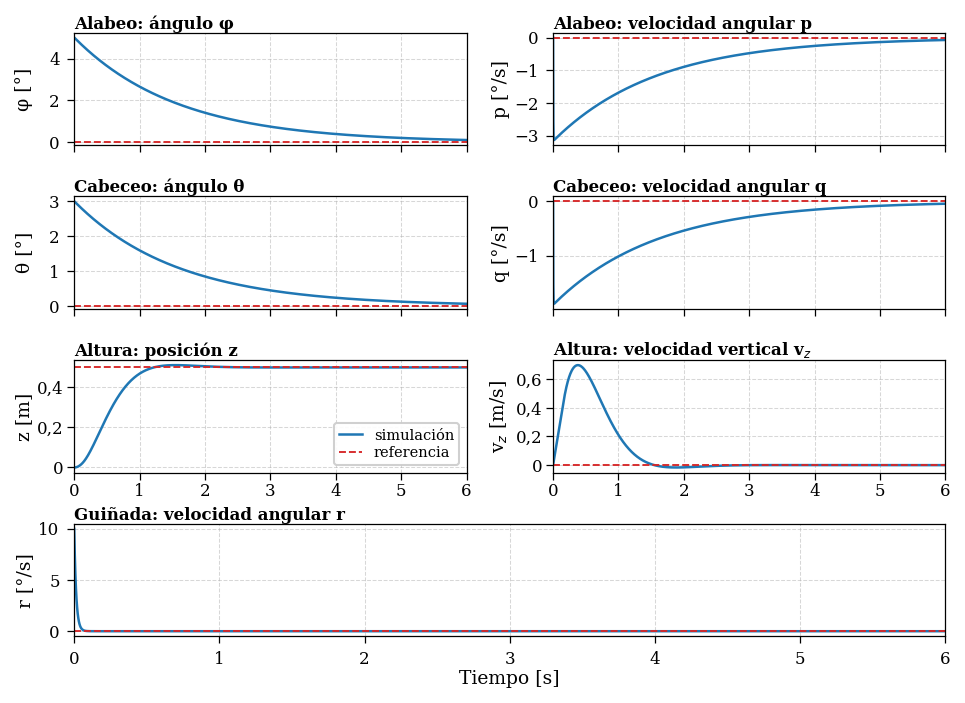

In [6]:
# ==============================================================================
# Estilo común de las figuras de datos del PIP (A4, márgenes de 2,5 cm)
# Se dibujan al tamaño final: 6,30 in de ancho = ancho útil de la página.
# ==============================================================================
import matplotlib.ticker as mticker

ANCHO_TESIS = 6.30          # in: 16,0 cm de ancho útil
ESTILO_TESIS = {
    "font.family": "serif", "font.size": 9,
    "axes.titlesize": 9, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 7.5, "legend.framealpha": 0.92, "legend.borderpad": 0.35,
    "legend.handlelength": 1.6, "legend.labelspacing": 0.25,
    "axes.grid": True, "grid.alpha": 0.5, "grid.linestyle": "--", "grid.linewidth": 0.5,
    "axes.linewidth": 0.6, "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "lines.linewidth": 1.0, "savefig.dpi": 300, "figure.dpi": 150,
}
_rc_cuaderno = dict(plt.rcParams)   # estilo del resto del cuaderno
plt.rcParams.update(ESTILO_TESIS)

def coma(x, pos=None):
    """Número con coma decimal y sin ceros sobrantes (formato del PIP)."""
    s = f"{x:.6g}"
    return s.replace("-", "−").replace(".", ",")

def ejes_con_coma(ax):
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(coma))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(coma))

def num(x, dec):
    return f"{x:.{dec}f}".replace("-", "−").replace(".", ",")

import os
os.makedirs("figuras", exist_ok=True)

# ==============================================================================
# Figura 3.5: respuesta simulada de los siete estados.
# Grilla de 2 x 4 a todo el ancho; el alto (4,55 in) es el espacio libre que deja
# la página de §3.3.7 en Word, para que la figura no pase a la página siguiente.
# ==============================================================================
fig = plt.figure(figsize=(ANCHO_TESIS, 4.55))
gs = fig.add_gridspec(4, 2)
paneles = [((0, 0), roll[:, 0],  "φ [°]",       "Alabeo: ángulo φ",            0),
           ((0, 1), roll[:, 1],  "p [°/s]",     "Alabeo: velocidad angular p", 0),
           ((1, 0), pitch[:, 0], "θ [°]",       "Cabeceo: ángulo θ",           0),
           ((1, 1), pitch[:, 1], "q [°/s]",     "Cabeceo: velocidad angular q", 0),
           ((2, 0), alt[:, 0],   "z [m]",       "Altura: posición z",          z_ref),
           ((2, 1), alt[:, 1],   "v$_z$ [m/s]", "Altura: velocidad vertical v$_z$", 0)]
ejes = []
for (i, j), y, et, tit, ref in paneles:
    ax = fig.add_subplot(gs[i, j]); ejes.append(ax)
    ax.plot(t, y, color="tab:blue", lw=1.2, label="simulación")
    ax.axhline(ref, color="tab:red", ls="--", lw=0.9, label="referencia")
    ax.set_ylabel(et, labelpad=2); ax.set_title(tit, loc="left", fontweight="bold", fontsize=8, pad=2)
    ax.set_xlim(0, 6); ejes_con_coma(ax); ax.tick_params(labelbottom=False)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(4, steps=[1, 2, 2.5, 5, 10]))
ax = fig.add_subplot(gs[3, :]); ejes.append(ax)
ax.plot(t, r, color="tab:blue", lw=1.2); ax.axhline(0, color="tab:red", ls="--", lw=0.9)
ax.set_ylabel("r [°/s]", labelpad=2)
ax.set_title("Guiñada: velocidad angular r", loc="left", fontweight="bold", fontsize=8, pad=2)
ax.set_xlim(0, 6); ax.set_xlabel("Tiempo [s]", labelpad=1); ejes_con_coma(ax)
ax.yaxis.set_major_locator(mticker.MaxNLocator(4, steps=[1, 2, 2.5, 5, 10]))
ejes[4].legend(loc="lower right", fontsize=7)
for a in ejes[4:6]: a.tick_params(labelbottom=True, pad=1.5)
for a in ejes[:6]: a.set_xticks([0, 1, 2, 3, 4, 5, 6])
fig.tight_layout(pad=0.25, h_pad=0.35, w_pad=1.0)
fig.align_ylabels(ejes[0::2][:3]); fig.align_ylabels(ejes[1:6:2])
fig.savefig("figuras/tesis_fig_3_5_simulacion.png"); display(fig); plt.close(fig)

plt.rcParams.update(_rc_cuaderno)   # se restituye el estilo del cuaderno


## 5. Ruido medido de los sensores y ajuste de R (Figura 4.2 y Tabla 4.2)

La covarianza de medición $R$ es la **varianza del ruido** de cada sensor (su raíz, $\sigma$, es el desvío típico).
Se mide con un solo registro, `telemetria/vuelos/vuelo_final.csv` (16/09), volado con las R asumidas de la sección 3.
El registro tiene dos tramos útiles:

1. **Reposo (primeros 8 s):** el dron está apoyado y con los motores apagados. Lo que miden los sensores es
   constante, así que toda su variación es ruido: la varianza de cada columna es directamente $R$.
   Se usa para el giróscopo.
2. **Vuelo (desde 5 s después del despegue):** el ángulo del acelerómetro varía por dos causas independientes, el
   movimiento real del dron y el ruido (vibración de los motores). Sus varianzas se suman, así que el ruido es
   $\sigma^2_{ruido} = \sigma^2_{acelerómetro} - \sigma^2_{estimado}$. Se usa para el acelerómetro, porque en vuelo
   su ruido es mucho mayor que en reposo.

En el giróscopo no se puede hacer la resta del punto 2: el filtro sigue casi por completo al giróscopo, de modo que
su estimación contiene el mismo ruido que se quiere medir.

Despegue a los 9.4 s
Reposo: 243 muestras   Vuelo: 9915 muestras (349 s)


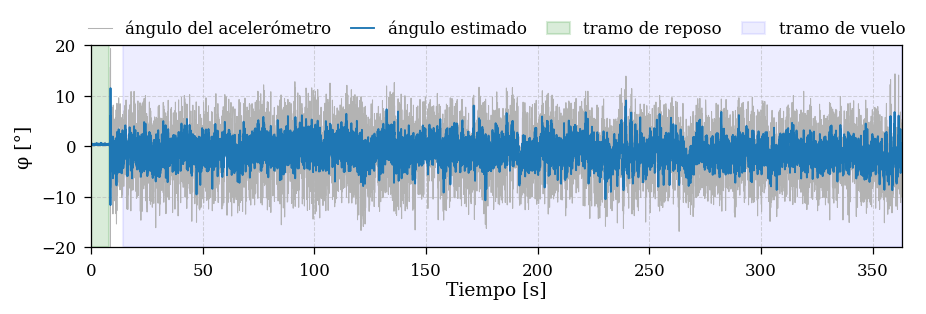

In [7]:
vf = pd.read_csv(os.path.join(VUELOS, "vuelo_final.csv"))

# El registro termina con un reinicio del micro por batería baja (el tiempo vuelve a cero): se descarta lo posterior
fin = np.where(np.diff(vf.timestamp_us.values) < 0)[0][0]
vf = vf.iloc[:fin + 1]
t = (vf.timestamp_us - vf.timestamp_us.iloc[0]) / 1e6        # tiempo [s]

t_despegue = t[vf.Alt_ToF > 0.15].iloc[0]                    # primer instante con el ToF por encima de 15 cm
reposo = vf[t < 8]                                           # apoyado, motores apagados
vuelo = vf[t > t_despegue + 5]                               # vuelo estacionario
print(f"Despegue a los {t_despegue:.1f} s")
print(f"Reposo: {len(reposo)} muestras   Vuelo: {len(vuelo)} muestras ({t.iloc[-1] - t_despegue - 5:.0f} s)")

with plt.rc_context(ESTILO_TESIS):            # tamaño final en el PIP (Figura 4.2)
    fig, ax = plt.subplots(figsize=(ANCHO_TESIS, 1.96))
    ax.plot(t, vf.Roll_Acc, color="0.7", lw=0.5, label="ángulo del acelerómetro")
    ax.plot(t, vf.Roll_Kalman, lw=0.9, label="ángulo estimado")
    ax.axvspan(0, 8, color="g", alpha=0.15, label="tramo de reposo")
    ax.axvspan(t_despegue + 5, t.iloc[-1], color="b", alpha=0.07, label="tramo de vuelo")
    ax.set_xlabel("Tiempo [s]", labelpad=1); ax.set_ylabel("φ [°]"); ax.set_ylim(-20, 20)
    ax.set_xlim(0, t.iloc[-1]); ejes_con_coma(ax)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=4, frameon=False, fontsize=8,
              borderaxespad=0.1, handlelength=1.4, columnspacing=1.2)
    fig.tight_layout(pad=0.25)
    fig.savefig("figuras/tesis_fig_4_2_ruido_alabeo.png"); display(fig); plt.close(fig)

In [8]:
# Giróscopo: varianza en reposo (alabeo y cabeceo comparten R en el firmware: se promedian)
R_gyr = (reposo.Roll_Gyr.var() + reposo.Pitch_Gyr.var()) / 2
R_r   = reposo.YawRate_Gyr.var()

# Acelerómetro: varianza en vuelo menos la del ángulo estimado (promedio de alabeo y cabeceo)
R_acc = ((vuelo.Roll_Acc.var() - vuelo.Roll_Kalman.var()) +
         (vuelo.Pitch_Acc.var() - vuelo.Pitch_Kalman.var())) / 2

# ToF: se conserva R_z = 0,005 m^2 (ver lectura)
R_v_att = np.diag([R_acc, R_gyr])

acc_rep = (reposo.Roll_Acc.var() + reposo.Pitch_Acc.var()) / 2
acc_tot = (vuelo.Roll_Acc.var() + vuelo.Pitch_Acc.var()) / 2
print("                asumida       medida")
print(f"Acelerómetro:   0.02 °²       {R_acc:.1f} °²  (reposo {acc_rep:.4f} °²; varianza total en vuelo {acc_tot:.1f} °²)")
print(f"Giróscopo p, q: 0.001 (°/s)²  {R_gyr:.5f} (°/s)²")
print(f"Giróscopo r:    0.001 (°/s)²  {R_r:.5f} (°/s)²")
print(f"ToF:            0.005 m²      {reposo.Alt_ToF.var():.1e} m²  (σ = {reposo.Alt_ToF.std()*1000:.1f} mm)")
print()
print(f"R ajustadas: acelerómetro {R_acc:.3g} °², giróscopo {R_gyr:.3g} (°/s)², guiñada {R_r:.3g} (°/s)², ToF {R_z} m²")
print()
print("// Líneas para firmware_dron/Config.h")
print("constexpr float R_roll_pitch[2][2] = {")
print(f"    {{{R_acc:.3g}f, 0.0f}},")
print(f"    {{0.0f, {R_gyr:.3g}f}}")
print("};")
print(f"constexpr float R_yaw = {R_r:.3g}f;")
print(f"constexpr float R_alt_scalar = {R_z:.3g}f; // Ruido del sensor láser ToF VL53L1X")

                asumida       medida
Acelerómetro:   0.02 °²       23.2 °²  (reposo 0.0139 °²; varianza total en vuelo 28.8 °²)
Giróscopo p, q: 0.001 (°/s)²  0.00380 (°/s)²
Giróscopo r:    0.001 (°/s)²  0.00302 (°/s)²
ToF:            0.005 m²      1.0e-06 m²  (σ = 1.0 mm)

R ajustadas: acelerómetro 23.2 °², giróscopo 0.0038 (°/s)², guiñada 0.00302 (°/s)², ToF 0.005 m²

// Líneas para firmware_dron/Config.h
constexpr float R_roll_pitch[2][2] = {
    {23.2f, 0.0f},
    {0.0f, 0.0038f}
};
constexpr float R_yaw = 0.00302f;
constexpr float R_alt_scalar = 0.005f; // Ruido del sensor láser ToF VL53L1X


**Lectura:**

* **Acelerómetro:** en vuelo su ruido es unas 1000 veces el valor asumido (σ de 4,8° frente a 0,14°), por la
  vibración de los motores y la aceleración del vehículo, que se confunden con inclinación. Con la $R$ asumida el
  filtro le creía demasiado. Como el ángulo estimado de ese vuelo arrastra parte de ese ruido, el valor medido es un
  mínimo; el máximo es la varianza total del acelerómetro en vuelo.
* **Giróscopo:** su ruido en reposo es unas 3 a 4 veces el asumido: mismo orden de magnitud.
* **ToF:** mide con alrededor de 1 mm de ruido, pero se conserva $R = 0{,}005$ m². El filtro corrige cada 4 ms con
  una lectura que se renueva cada unos 33 ms, es decir, con el mismo valor repetido unas 8 veces. Con la $R$ medida
  el filtro seguiría esa escalera y la velocidad vertical estimada saltaría en cada lectura nueva.

## 6. Ganancias de Kalman con las R ajustadas (Tabla 4.3, ajustadas)

In [9]:
K_att = kalman(R_v_att, R_r)

Alabeo y cabeceo: K =
 [[0.0206 0.004 ]
 [0.     0.9337]]
   medición:   σ_φ = 4.814 °,  σ_p = 0.0617 °/s
   estimación: σ_φ = 0.690 °,  σ_p = 0.0596 °/s
Guiñada: K = 0.8825
   medición:   σ_r = 0.0549 °/s,  estimación: σ_r = 0.0516 °/s
Altura: K = [0.3707 1.1259]
   medición:   σ_z = 0.0707 m,  estimación: σ_z = 0.0426 m


## 7. Simulación del observador: R asumidas frente a R ajustadas (Figura 4.3)

Se simula exactamente el modelo que supone el filtro. El vehículo parte del reposo y su estado evoluciona como
$x(k+1) = \Phi\,x(k) + w(k)$, con $w$ de covarianza $Q_w$; las mediciones son $y(k) = x(k) + v(k)$, con $v$ de
covarianza $R$ igual al ruido medido (sección 5). Ambos filtros arrancan en cero, como en el firmware, y procesan las
mismas mediciones: uno con la ganancia de las R asumidas (sección 3) y otro con la de las R ajustadas (sección 6).
Como la simulación cumple las hipótesis del filtro, el desvío del error con las R ajustadas tiene que coincidir con
la incertidumbre de la estimación de la sección 6.


Medición:     ángulo 4.85°,  velocidad angular 0.061 °/s
R asumidas  : ángulo 2.79° (42 % menos),  velocidad angular 0.060 °/s (2 % menos)
R ajustadas : ángulo 0.68° (86 % menos),  velocidad angular 0.059 °/s (3 % menos)


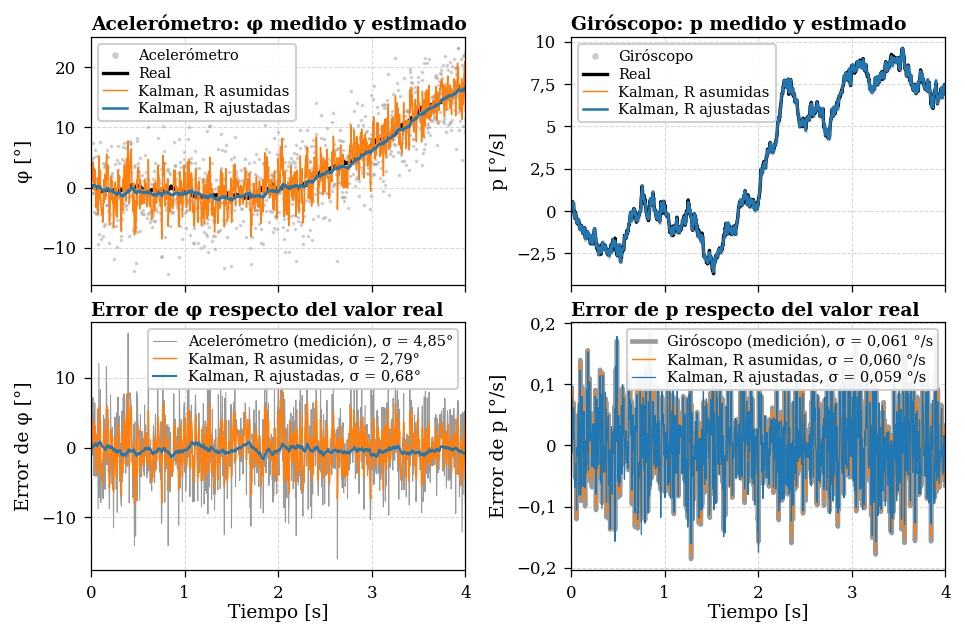

In [10]:
np.random.seed(42)
N = 25000                                   # 100 s a 250 Hz: estadística estable
t = np.arange(N) * h
x = np.zeros((N, 2))                        # estado real [φ, p], parte del reposo
for k in range(N - 1):
    x[k + 1] = Phi @ x[k] + np.random.multivariate_normal([0, 0], Qw_att)
y = x + np.random.multivariate_normal([0, 0], R_v_att, N)   # acelerómetro y giróscopo

def filtro(K):
    xh = np.zeros((N, 2))                   # arranca en cero, como el firmware
    for k in range(1, N):
        xp = Phi @ xh[k - 1]                # predicción
        xh[k] = xp + K @ (y[k] - xp)        # corrección
    return xh

xh0, xh = filtro(K0_att), filtro(K_att)
s_med = (y - x).std(axis=0)             # desvío del ruido efectivamente simulado
print(f"Medición:     ángulo {s_med[0]:.2f}°,  velocidad angular {s_med[1]:.3f} °/s")
for nombre, x_ in (("R asumidas", xh0), ("R ajustadas", xh)):
    e = (x - x_).std(axis=0)
    print(f"{nombre:12s}: ángulo {e[0]:.2f}° ({100*(1 - e[0]/s_med[0]):.0f} % menos),"
          f"  velocidad angular {e[1]:.3f} °/s ({100*(1 - e[1]/s_med[1]):.0f} % menos)")

c0, c1 = "tab:orange", "tab:blue"
v = t <= 4.0                                # se grafican los primeros 4 s
with plt.rc_context(ESTILO_TESIS):            # tamaño final en el PIP (Figura 4.3)
  fig, axs = plt.subplots(2, 2, figsize=(ANCHO_TESIS, 4.11), sharex=True)
  for j, (sensor, nom, un) in enumerate((("Acelerómetro", "φ", "°"), ("Giróscopo", "p", "°/s"))):
    ax = axs[0, j]
    ax.plot(t[v], y[v, j], ".", color="0.6", alpha=0.4, ms=1.5, label=sensor)
    ax.plot(t[v], x[v, j], "k", lw=1.6, label="Real")
    ax.plot(t[v], xh0[v, j], color=c0, lw=0.7, label="Kalman, R asumidas")
    ax.plot(t[v], xh[v, j], color=c1, lw=1.2, label="Kalman, R ajustadas")
    ax.set_ylabel(f"{nom} [{un}]"); ax.legend(loc="upper left", fontsize=7, markerscale=3)
    ax.set_title(f"{sensor}: {nom} medido y estimado", loc="left", fontweight="bold", pad=3)
    ejes_con_coma(ax)
    ax = axs[1, j]                          # error respecto del valor real
    d = 2 if j == 0 else 3                   # decimales del desvío en la leyenda
    sd = lambda e: f"σ = {e[:, j].std():.{d}f}{un if j == 0 else ' ' + un}".replace(".", ",")   # desvío en los 100 s
    ax.plot(t[v], (y - x)[v, j], color="0.6", lw=(0.5, 2.2)[j], label=f"{sensor} (medición), {sd(y - x)}")  # en p, más gruesa: las tres curvas se superponen
    ax.plot(t[v], (xh0 - x)[v, j], color=c0, lw=0.7, label=f"Kalman, R asumidas, {sd(xh0 - x)}")
    ax.plot(t[v], (xh - x)[v, j], color=c1, lw=(1.0, 0.6)[j], label=f"Kalman, R ajustadas, {sd(xh - x)}")
    ax.set_xlabel("Tiempo [s]", labelpad=1); ax.set_ylabel(f"Error de {nom} [{un}]"); ax.set_xlim(0, 4)
    ax.set_title(f"Error de {nom} respecto del valor real", loc="left", fontweight="bold", pad=3)
    ax.legend(loc="upper right", fontsize=7); ejes_con_coma(ax)
  fig.tight_layout(pad=0.25, h_pad=0.5, w_pad=1.0)
  fig.savefig("figuras/tesis_fig_4_3_observador.png"); display(fig); plt.close(fig)


## 8. Vuelo final con el diseño ajustado (§4.3, Figura 4.4)

Vuelo con el firmware final (R ajustadas y trims de `Config.h`) desde batería llena hasta agotarla:
`telemetria/vuelos/vuelo_final_ajustado.csv`. El registro termina con un reinicio del microcontrolador por batería
agotada (el tiempo vuelve a cero); se usa hasta ese instante.

In [11]:
vf2 = pd.read_csv(os.path.join(VUELOS, "vuelo_final_ajustado.csv"))
fin = np.where(np.diff(vf2.timestamp_us.values) < 0)[0][0]      # reinicio por batería agotada
vf2 = vf2.iloc[:fin + 1]
t2 = ((vf2.timestamp_us - vf2.timestamp_us.iloc[0]) / 1e6).values
t_desp = t2[(vf2.Alt_ToF > 0.15).values][0]
t_fin = t2[-1]
aire = t2 > t_desp
TRIM_ROLL, TRIM_PITCH, Z_REF = -0.7, -1.0, 0.50

def media_movil(y, seg=5):
    n = int(seg / 0.02)                                        # telemetría a 50 Hz
    return pd.Series(np.asarray(y)).rolling(n, center=True, min_periods=1).mean().values

z_mm = media_movil(vf2.Alt_Kalman, 30)
t_bajo = t2[(t2 > t_desp + 30) & (z_mm < 0.40)][0]            # la altura media (30 s) cae bajo 0,40 m
v30 = vf2[(t2 > t_desp + 5) & (t2 < t_desp + 305)]              # primeros 5 min de vuelo
vueltas = np.sum(vf2.YawRate_Gyr.values[aire][:-1] * np.diff(t2[aire])) / 360
t_aire = t_fin - t_desp
print(f"Tiempo en el aire: {t_aire:.0f} s ({int(t_aire//60)} min {t_aire%60:.0f} s)")
print(f"Batería: {vf2.VBat.iloc[0]:.2f} V en reposo, {vf2.VBat[t2 > t_desp + 2].iloc[0]:.2f} V al despegar, "
      f"{vf2.VBat.iloc[-1]:.2f} V al reiniciarse")
print(f"Altura en los primeros 5 min: media {v30.Alt_Kalman.mean():.2f} m, desvío {v30.Alt_Kalman.std()*100:.1f} cm "
      f"(referencia {Z_REF} m)")
print(f"La altura media cae bajo 0,40 m a los {t_bajo - t_desp:.0f} s de vuelo")
va = vf2[aire]
print(f"Alabeo sostenido: {va.Roll_Kalman.mean():+.2f}° (trim {TRIM_ROLL}°)   "
      f"cabeceo sostenido: {va.Pitch_Kalman.mean():+.2f}° (trim {TRIM_PITCH}°)")
print(f"Guiñada: {va.YawRate_Gyr.mean():.1f} °/s de media, {abs(vueltas):.1f} vueltas en todo el vuelo")
print(f"Temperatura de la IMU: entre {vf2.temp.min():.1f} y {vf2.temp.max():.1f} °C")
print(f"Altura media por minuto de vuelo [m]:", np.round(va.groupby(((t2[aire] - t_desp) // 60).astype(int)).Alt_Kalman.mean().values, 2))

Tiempo en el aire: 720 s (12 min 0 s)
Batería: 4.19 V en reposo, 3.40 V al despegar, 2.62 V al reiniciarse
Altura en los primeros 5 min: media 0.48 m, desvío 4.4 cm (referencia 0.5 m)
La altura media cae bajo 0,40 m a los 329 s de vuelo
Alabeo sostenido: -0.03° (trim -0.7°)   cabeceo sostenido: -0.54° (trim -1.0°)
Guiñada: -6.1 °/s de media, 12.4 vueltas en todo el vuelo
Temperatura de la IMU: entre 27.8 y 29.8 °C
Altura media por minuto de vuelo [m]: [0.54 0.49 0.45 0.46 0.45 0.4  0.38 0.38 0.36 0.35 0.33 0.16 0.11]


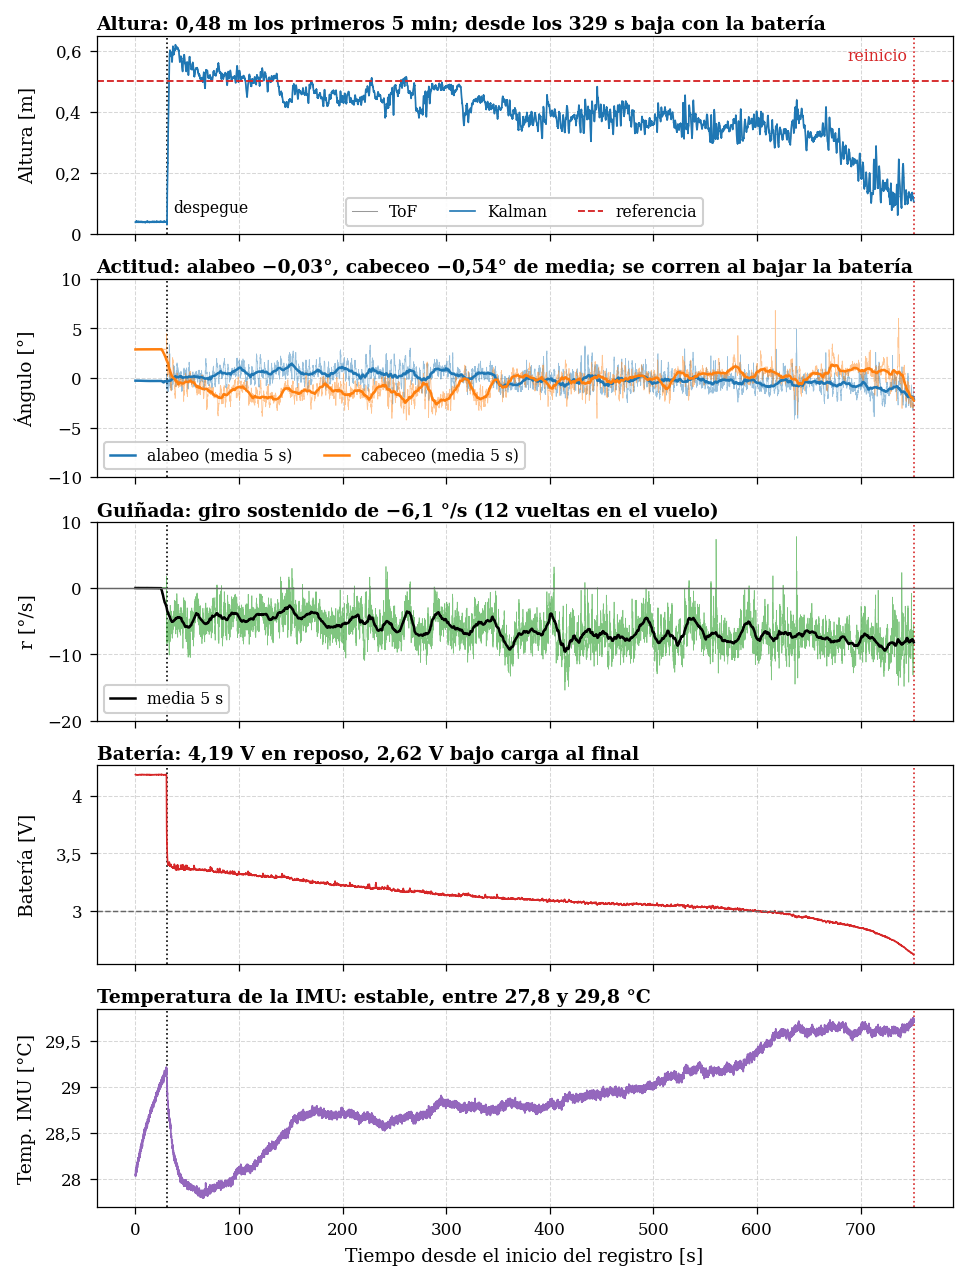

In [12]:
plt.rcParams.update(ESTILO_TESIS)     # tamaño final del PIP (ver celda de la Figura 3.5)
# ==============================================================================
# Figura 4.4: resumen del vuelo final (5 paneles a todo el ancho)
# ==============================================================================
fig, axs = plt.subplots(5, 1, figsize=(ANCHO_TESIS, 8.4), sharex=True)
for ax in axs:
    ax.axvline(t_desp, color="k", ls=":", lw=0.8); ax.axvline(t_fin, color="tab:red", ls=":", lw=0.8)
    ejes_con_coma(ax)

ax = axs[0]
ax.plot(t2, vf2.Alt_ToF, color="0.6", lw=0.5, label="ToF")
ax.plot(t2, vf2.Alt_Kalman, color="tab:blue", lw=0.8, label="Kalman")
ax.axhline(Z_REF, color="tab:red", ls="--", lw=0.9, label="referencia")
ax.set_ylabel("Altura [m]"); ax.legend(loc="lower center", ncol=3)
ax.set_title(f"Altura: {num(v30.Alt_Kalman.mean(), 2)} m los primeros 5 min; desde los "
             f"{t_bajo - t_desp:.0f} s baja con la batería", loc="left", fontweight="bold", pad=3)
ax.text(t_desp + 6, 0.07, "despegue", fontsize=7.5)
ax.text(t_fin - 6, 0.57, "reinicio", fontsize=7.5, ha="right", color="tab:red")

ax = axs[1]
ax.plot(t2, vf2.Roll_Kalman, lw=0.35, alpha=0.45, color="tab:blue")
ax.plot(t2, vf2.Pitch_Kalman, lw=0.35, alpha=0.45, color="tab:orange")
ax.plot(t2, media_movil(vf2.Roll_Kalman), color="tab:blue", lw=1.2, label="alabeo (media 5 s)")
ax.plot(t2, media_movil(vf2.Pitch_Kalman), color="tab:orange", lw=1.2, label="cabeceo (media 5 s)")
ax.set_ylim(-10, 10); ax.set_ylabel("Ángulo [°]"); ax.legend(loc="lower left", ncol=2)
ax.set_title(f"Actitud: alabeo {num(va.Roll_Kalman.mean(), 2)}°, cabeceo {num(va.Pitch_Kalman.mean(), 2)}° "
             "de media; se corren al bajar la batería", loc="left", fontweight="bold", pad=3)

ax = axs[2]
ax.plot(t2, vf2.YawRate_Gyr, color="tab:green", lw=0.35, alpha=0.6)
ax.plot(t2, media_movil(vf2.YawRate_Gyr), "k", lw=1.2, label="media 5 s")
ax.axhline(0, color="0.4", lw=0.7); ax.set_ylim(-20, 10)
ax.set_ylabel("r [°/s]"); ax.legend(loc="lower left")
ax.set_title(f"Guiñada: giro sostenido de {num(va.YawRate_Gyr.mean(), 1)} °/s "
             f"({abs(vueltas):.0f} vueltas en el vuelo)", loc="left", fontweight="bold", pad=3)

ax = axs[3]
ax.plot(t2, vf2.VBat, color="tab:red", lw=0.8)
ax.axhline(3.0, color="0.4", ls="--", lw=0.7)
ax.set_ylabel("Batería [V]")
ax.set_title(f"Batería: {num(vf2.VBat.iloc[0], 2)} V en reposo, {num(vf2.VBat.iloc[-1], 2)} V "
             "bajo carga al final", loc="left", fontweight="bold", pad=3)

ax = axs[4]
ax.plot(t2, vf2.temp, color="tab:purple", lw=0.8)
ax.set_ylabel("Temp. IMU [°C]"); ax.set_xlabel("Tiempo desde el inicio del registro [s]")
ax.set_title(f"Temperatura de la IMU: estable, entre {num(vf2.temp.min(), 1)} y {num(vf2.temp.max(), 1)} °C",
             loc="left", fontweight="bold", pad=3)
fig.tight_layout(pad=0.25, h_pad=0.7)
fig.align_ylabels(axs)
fig.savefig("figuras/tesis_fig_4_4_vuelo_final.png")
display(fig); plt.close(fig)


plt.rcParams.update(_rc_cuaderno)


## 9. Verificación del ruido en el vuelo final (Figura 4.5)

Se repite la medición de la sección 5 con este vuelo. Ahora el filtro usa las R ajustadas y casi no sigue al
acelerómetro, así que la resta $\sigma^2_{acel} - \sigma^2_{est}$ ya no subestima el ruido.
Reposo: los primeros 25 s, con el vehículo quieto y los motores apagados.

                           R asumida  R ajustada  Vuelo final
Acelerómetro alabeo [°²]        0.02        23.2         20.1
Acelerómetro cabeceo [°²]       0.02        23.2         9.89
Giróscopo p, q [(°/s)²]        0.001      0.0038      0.00221
Giróscopo r [(°/s)²]           0.001     0.00302      0.00193
ToF [m²]                       0.005       0.005     7.77e-07

Innovación del ángulo: alabeo 19.4 °², cabeceo 9.4 °²;  el filtro espera 23.7 °²


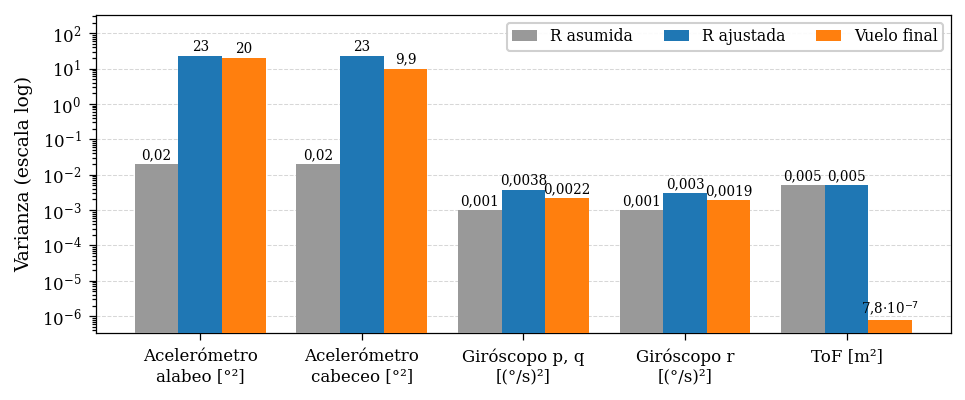

In [13]:
rep2 = vf2[t2 < 25]
v2 = vf2[(t2 > t_desp + 5) & (t2 < t_fin - 5)]

medido = {
    "Acelerómetro\nalabeo [°²]":  v2.Roll_Acc.var() - v2.Roll_Kalman.var(),
    "Acelerómetro\ncabeceo [°²]": v2.Pitch_Acc.var() - v2.Pitch_Kalman.var(),
    "Giróscopo p, q\n[(°/s)²]":   (rep2.Roll_Gyr.var() + rep2.Pitch_Gyr.var()) / 2,
    "Giróscopo r\n[(°/s)²]":      rep2.YawRate_Gyr.var(),
    "ToF [m²]":                   rep2.Alt_ToF.var(),
}
asumida = [0.02, 0.02, 0.001, 0.001, 0.005]
ajustada = [R_acc, R_acc, R_gyr, R_r, R_z]
tabla = pd.DataFrame({"R asumida": asumida, "R ajustada": ajustada, "Vuelo final": list(medido.values())},
                     index=[k.replace("\n", " ") for k in medido])
print(tabla.to_string(float_format=lambda x: f"{x:.3g}"))

# Chequeo de consistencia: la diferencia medición - estimación debería variar como R + P (lo que espera el filtro)
_, P_aj, _ = ct.dlqe(Phi, np.eye(2), np.eye(2), Qw_att, R_v_att)
print()
print(f"Innovación del ángulo: alabeo {(v2.Roll_Acc - v2.Roll_Kalman).var():.1f} °², "
      f"cabeceo {(v2.Pitch_Acc - v2.Pitch_Kalman).var():.1f} °²;  el filtro espera {R_acc + P_aj[0, 0]:.1f} °²")

x = np.arange(len(medido)); w = 0.27
def etq(v):                                   # etiqueta de barra con coma decimal
    if v < 1e-4:
        m, e = f"{v:.1e}".split("e"); return f"{m.replace('.', ',')}·10$^{{{int(e)}}}$"
    return f"{v:.2g}".replace(".", ",")
with plt.rc_context(ESTILO_TESIS):            # tamaño final en el PIP (Figura 4.5)
    fig, ax = plt.subplots(figsize=(ANCHO_TESIS, 2.53))
    for i, (col, c) in enumerate(zip(tabla.columns, ["0.6", "tab:blue", "tab:orange"])):
        b = ax.bar(x + (i - 1) * w, tabla[col], w, color=c, label=col, zorder=3)
        ax.bar_label(b, labels=[etq(v) for v in tabla[col]], fontsize=6.5, padding=1)
    ax.set_yscale("log"); ax.set_xticks(x, list(medido.keys()))
    ax.set_ylim(top=ax.get_ylim()[1] * 6); ax.grid(axis="x", visible=False)
    ax.set_ylabel("Varianza (escala log)"); ax.legend(loc="upper right", ncol=3, fontsize=7.5)
    fig.tight_layout(pad=0.25)
    fig.savefig("figuras/tesis_fig_4_5_ruido.png"); display(fig); plt.close(fig)

## 10. Estados medidos frente a estimados por Kalman (Figura 4.6)

Todo el vuelo final, con los mismos paneles y colores de la aplicación de telemetría (`Telemetria.py`), en tonos
más oscuros para fondo blanco. Para cada estado se superpone la medición del sensor con la estimación del filtro.
La velocidad vertical no se mide: solo existe la estimación.

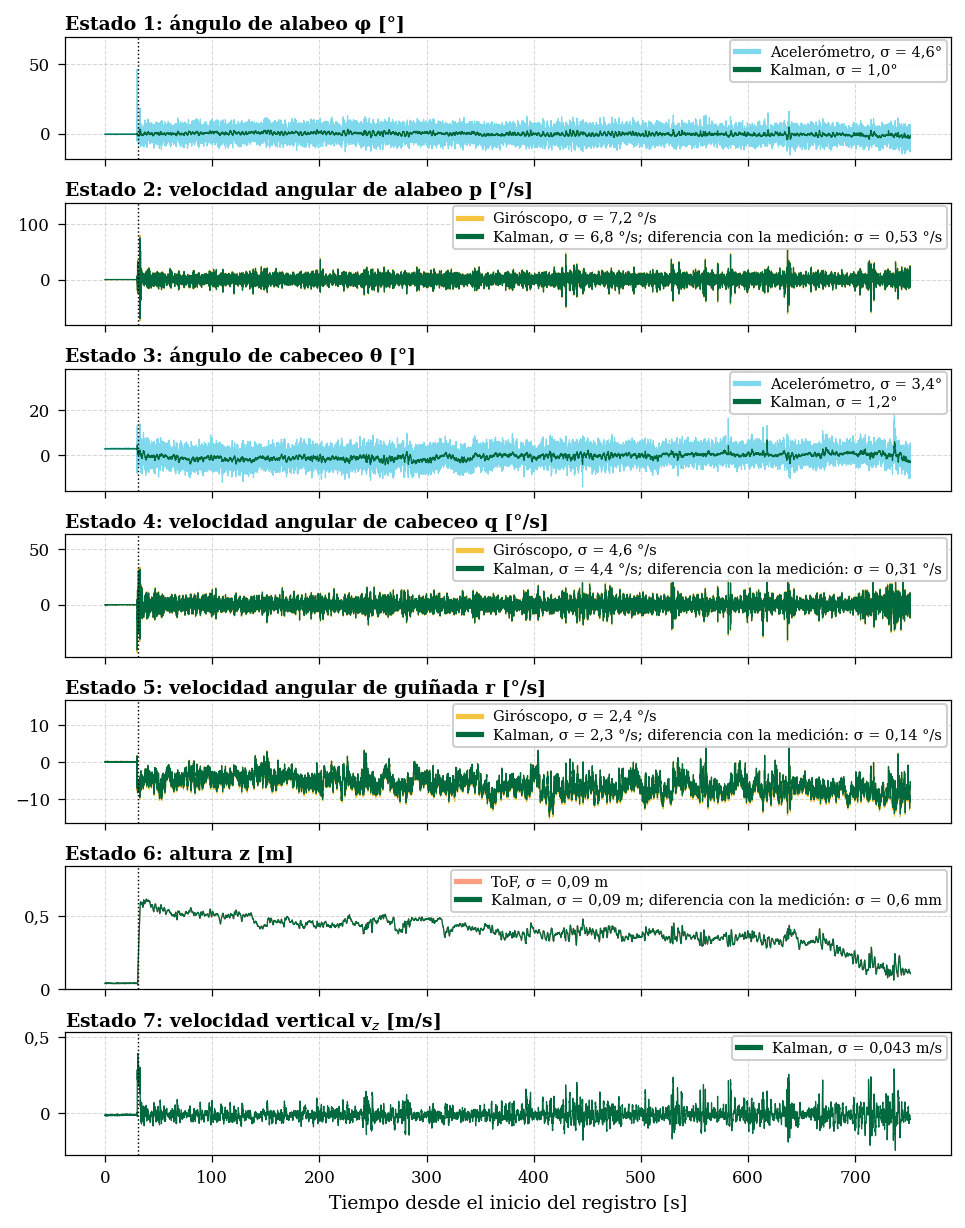

φ: desvío medición 4.586, estimación 0.967, diferencia 4.4091
θ: desvío medición 3.356, estimación 1.173, diferencia 3.0599
p: desvío medición 7.239, estimación 6.825, diferencia 0.5335
q: desvío medición 4.634, estimación 4.378, diferencia 0.3110
r: desvío medición 2.398, estimación 2.302, diferencia 0.1394
z: desvío medición 0.092, estimación 0.092, diferencia 0.0006
v_z estimada: desvío 0.043 m/s


In [14]:
plt.rcParams.update(ESTILO_TESIS)     # tamaño final del PIP (ver celda de la Figura 3.5)
# ==============================================================================
# Figura 4.6: los siete estados medidos y estimados en todo el vuelo final
# ==============================================================================
d = vf2
ACEL, GIRO, TOF, KALMAN = "#7FD8EC", "#F5C542", "#FF9E80", "#00693E"
estados = [("Estado 1: ángulo de alabeo φ [°]",              "Roll_Acc",    "acelerómetro", ACEL, "Roll_Kalman"),
           ("Estado 2: velocidad angular de alabeo p [°/s]", "Roll_Gyr",    "giróscopo",    GIRO, "RollRate_Kalman"),
           ("Estado 3: ángulo de cabeceo θ [°]",             "Pitch_Acc",   "acelerómetro", ACEL, "Pitch_Kalman"),
           ("Estado 4: velocidad angular de cabeceo q [°/s]","Pitch_Gyr",   "giróscopo",    GIRO, "PitchRate_Kalman"),
           ("Estado 5: velocidad angular de guiñada r [°/s]","YawRate_Gyr", "giróscopo",    GIRO, "YawRate_Kalman"),
           ("Estado 6: altura z [m]",                        "Alt_ToF",     "ToF",          TOF,  "Alt_Kalman"),
           ("Estado 7: velocidad vertical v$_z$ [m/s]",      None,          None,           None, "Vz_Kalman")]
v2 = vf2[(t2 > t_desp + 5) & (t2 < t_fin - 5)]
def fmt(x, dec, un):
    return f"{x:.{dec}f}{'' if un == '°' else ' '}{un}".replace(".", ",")
formato = {"Roll_Kalman": ("°", 1, None, None), "Pitch_Kalman": ("°", 1, None, None),
           "RollRate_Kalman": ("°/s", 1, 2, "°/s"), "PitchRate_Kalman": ("°/s", 1, 2, "°/s"),
           "YawRate_Kalman": ("°/s", 1, 2, "°/s"), "Alt_Kalman": ("m", 2, 1, "mm"),
           "Vz_Kalman": ("m/s", 3, None, None)}

fig, axs = plt.subplots(7, 1, figsize=(ANCHO_TESIS, 8.05), sharex=True)
for ax, (titulo, med, sensor, color, est) in zip(axs, estados):
    un, dec, dec_d, un_d = formato[est]
    etq_k = f"Kalman, σ = {fmt(v2[est].std(), dec, un)}"
    if med is not None and dec_d is not None:
        dif = (v2[med] - v2[est]).std() * (1000 if un_d == "mm" else 1)
        etq_k += f"; diferencia con la medición: σ = {fmt(dif, dec_d, un_d)}"
    series = [(d[est], KALMAN, 0.6, etq_k)]
    if med is not None:
        series.append((d[med], color, 0.6, f"{sensor[0].upper() + sensor[1:]}, σ = {fmt(v2[med].std(), dec, un)}"))
    for y, c, lw, nombre in sorted(series, key=lambda s: -np.std(s[0][aire])):
        ax.plot(t2, y, color=c, lw=lw, label=nombre)
    ax.axvline(t_desp, color="k", ls=":", lw=0.7)
    vals = np.concatenate([np.asarray(y) for y, *_ in series])
    lo, hi = np.nanmin(vals), np.nanmax(vals)
    filas = 1 if len(series) == 1 else 2
    ax.set_ylim(lo - 0.05 * (hi - lo), hi + (0.38 if filas == 2 else 0.22) * (hi - lo))
    ax.set_title(titulo, loc="left", fontweight="bold", pad=3)
    ejes_con_coma(ax)
    leg = ax.legend(loc="upper right", fontsize=7, ncol=1, borderaxespad=0.25)
    for linea in leg.get_lines(): linea.set_linewidth(2.5)
axs[-1].set_xlabel("Tiempo desde el inicio del registro [s]")
fig.tight_layout(pad=0.25, h_pad=0.6)
fig.align_ylabels(axs)
fig.savefig("figuras/tesis_fig_4_6_estados.png")
display(fig); plt.close(fig)

plt.rcParams.update(_rc_cuaderno)

# Resumen numérico sobre todo el vuelo: desvío de cada señal y desvío de la diferencia medición - estimación
for et, m, e in [("φ", "Roll_Acc", "Roll_Kalman"), ("θ", "Pitch_Acc", "Pitch_Kalman"),
                 ("p", "Roll_Gyr", "RollRate_Kalman"), ("q", "Pitch_Gyr", "PitchRate_Kalman"),
                 ("r", "YawRate_Gyr", "YawRate_Kalman"), ("z", "Alt_ToF", "Alt_Kalman")]:
    print(f"{et}: desvío medición {v2[m].std():.3f}, estimación {v2[e].std():.3f}, "
          f"diferencia {(v2[m] - v2[e]).std():.4f}")
print(f"v_z estimada: desvío {v2.Vz_Kalman.std():.3f} m/s")

## 11. Beneficio del filtro: ángulo frente a velocidad angular (cifras de §4.3 sobre la Figura 4.6)

En la Figura 4.6 la velocidad angular estimada parece más "ruidosa" que el ángulo estimado. No lo es: es movimiento
real. Se compara, para roll, el ruido propio de cada sensor con cuánto varía la señal en vuelo:

* **Ruido del sensor:** giróscopo, desvío en reposo con motores apagados; acelerómetro, desvío del ruido en vuelo
  (sección 9).
* **Medición en vuelo:** desvío de lo que mide el sensor durante el vuelo.
* **Movimiento real (Kalman):** desvío del estado estimado durante el vuelo.

In [15]:
s_ruido_acc = np.sqrt(v2.Roll_Acc.var() - v2.Roll_Kalman.var())
s_ruido_gyr = rep2.Roll_Gyr.std()
barras = {"Ángulo de roll φ [°]":            [v2.Roll_Acc.std(), s_ruido_acc, v2.Roll_Kalman.std()],
          "Velocidad angular de roll p [°/s]": [v2.Roll_Gyr.std(), s_ruido_gyr, v2.RollRate_Kalman.std()]}
for k, (m, r, e) in barras.items():
    print(f"{k:34s} medición {m:6.3f}   ruido del sensor {r:6.3f}   movimiento real (Kalman) {e:6.3f}   "
          f"movimiento/ruido = {e/r:.2f}")
print(f"Relación entre desvíos p/φ del estimado: {v2.RollRate_Kalman.std()/v2.Roll_Kalman.std():.1f} rad/s "
      f"(≈ {v2.RollRate_Kalman.std()/v2.Roll_Kalman.std()/(2*np.pi):.1f} Hz)")
print(f"Ruido que el ángulo del acelerómetro metería en el comando: {L_att[0]*s_ruido_acc:.0f} cuentas (1σ)")


Ángulo de roll φ [°]               medición  4.586   ruido del sensor  4.482   movimiento real (Kalman)  0.967   movimiento/ruido = 0.22
Velocidad angular de roll p [°/s]  medición  7.239   ruido del sensor  0.049   movimiento real (Kalman)  6.825   movimiento/ruido = 139.36
Relación entre desvíos p/φ del estimado: 7.1 rad/s (≈ 1.1 Hz)
Ruido que el ángulo del acelerómetro metería en el comando: 19 cuentas (1σ)


## 12. Polos en el plano z: planta, lazo cerrado y observador (Figura 4.7)

Polos de cada subsistema a lazo abierto (autovalores de $\mathbf{\Phi}$), a lazo cerrado con el LQR
(autovalores de $\mathbf{\Phi} - \mathbf{\Gamma L}$) y del observador de Kalman con las R ajustadas
(autovalores de $(\mathbf{I} - \mathbf{KC})\mathbf{\Phi}$, la dinámica del error de estimación).
Por el principio de separación, los polos del sistema LQG completo son la unión de los del control y los del
observador. Los polos repetidos se indican con su multiplicidad (×2 = polo doble). Para cada polo se da su
equivalente continuo $s = \ln(z)/h$ y su constante de tiempo $\tau = -1/\mathrm{Re}(s)$.
Alabeo y cabeceo son subsistemas idénticos: cada polo de ese panel aparece una vez en cada uno.

In [16]:
K_yaw_aj, _, _ = ct.dlqe(Phi_yaw, np.eye(1), np.eye(1), Qw_yaw, np.array([[R_r]]))
K_alt_aj, _, _ = ct.dlqe(Phi, np.eye(2), np.array([[1.0, 0.0]]), Qw_alt, np.array([[R_z]]))
canales_p = {"Alabeo y cabeceo": (Phi, Gam_att, L_att.reshape(1, -1), K_att, np.eye(2)),
             "Guiñada":          (Phi_yaw, Gam_yaw, np.array([[L_yaw]]), K_yaw_aj, np.eye(1)),
             "Altura":           (Phi, Gam_alt, L_alt.reshape(1, -1), K_alt_aj, np.array([[1.0, 0.0]]))}

def agrupar(p, tol=1e-6):
    grupos = []
    for z in p:
        for g in grupos:
            if abs(z - g[0]) < tol:
                g[1] += 1; break
        else:
            grupos.append([z, 1])
    return grupos

polos = {}
for n, (F, G, Lk, Kk, C) in canales_p.items():
    polos[n] = {"Lazo abierto (planta)": agrupar(np.linalg.eigvals(F)),
                "Lazo cerrado (LQR)":    agrupar(np.linalg.eigvals(F - G @ Lk)),
                "Observador (Kalman)":   agrupar(np.linalg.eigvals((np.eye(len(F)) - Kk @ C) @ F))}
    print(f"--- {n} ---")
    for tipo, gr in polos[n].items():
        for z, mult in gr:
            s = np.log(complex(z)) / h
            tau = "∞ (integrador)" if abs(s.real) < 1e-9 else f"{-1000/s.real:.1f} ms"
            print(f"  {tipo:22s} z = {complex(z).real:.5f}{complex(z).imag:+.5f}j   "
                  f"{'doble' if mult == 2 else 'simple':6s}   τ = {tau}")

--- Alabeo y cabeceo ---
  Lazo abierto (planta)  z = 1.00000+0.00000j   doble    τ = ∞ (integrador)
  Lazo cerrado (LQR)     z = 0.99747+0.00000j   simple   τ = 1581.1 ms
  Lazo cerrado (LQR)     z = 0.18489+0.00000j   simple   τ = 2.4 ms
  Observador (Kalman)    z = 0.97944+0.00000j   simple   τ = 192.6 ms
  Observador (Kalman)    z = 0.06628+0.00000j   simple   τ = 1.5 ms
--- Guiñada ---
  Lazo abierto (planta)  z = 1.00000+0.00000j   simple   τ = ∞ (integrador)
  Lazo cerrado (LQR)     z = 0.74668+0.00000j   simple   τ = 13.7 ms
  Observador (Kalman)    z = 0.11751+0.00000j   simple   τ = 1.9 ms
--- Altura ---
  Lazo abierto (planta)  z = 1.00000+0.00000j   doble    τ = ∞ (integrador)
  Lazo cerrado (LQR)     z = 0.99002+0.00828j   simple   τ = 400.1 ms
  Lazo cerrado (LQR)     z = 0.99002-0.00828j   simple   τ = 400.1 ms
  Observador (Kalman)    z = 0.63719+0.00000j   simple   τ = 8.9 ms
  Observador (Kalman)    z = 0.98759+0.00000j   simple   τ = 320.2 ms


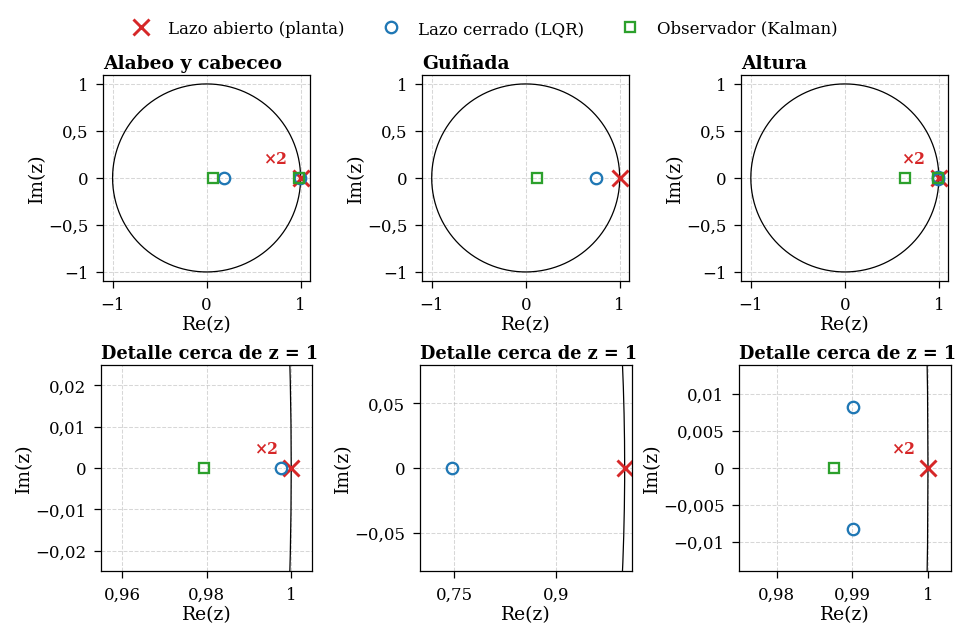

In [17]:
estilo = {"Lazo abierto (planta)": ("x", "tab:red", 14),
          "Lazo cerrado (LQR)":    ("o", "tab:blue", 10),
          "Observador (Kalman)":   ("s", "tab:green", 9)}
zoom = {"Alabeo y cabeceo": (0.955, 1.005, 0.025), "Guiñada": (0.70, 1.01, 0.08), "Altura": (0.975, 1.003, 0.014)}
th = np.linspace(0, 2*np.pi, 600)
estilo = {k: (mk, col, ms * 0.55) for k, (mk, col, ms) in estilo.items()}
with plt.rc_context(ESTILO_TESIS):            # tamaño final en el PIP (Figura 4.7)
  fig, axs = plt.subplots(2, 3, figsize=(ANCHO_TESIS, 4.10))
  for j, (n, tipos) in enumerate(polos.items()):
    for i, ax in enumerate(axs[:, j]):
        ax.plot(np.cos(th), np.sin(th), "k", lw=0.6)
        for tipo, gr in tipos.items():
            mk, col, ms = estilo[tipo]
            for k, (z, mult) in enumerate(gr):
                z = complex(z)
                ax.plot(z.real, z.imag, mk, ms=ms, mew=1.4 if mk == "x" else 1.1,
                        mfc="none" if mk != "x" else None, color=col, label=tipo if k == 0 else None)
                if mult > 1:
                    ax.annotate(f"×{mult}", (z.real, z.imag), textcoords="offset points",
                                xytext=(-6, 7), ha="right", fontsize=7.5, color=col, fontweight="bold")
        ax.set_xlabel("Re(z)", labelpad=1); ax.set_ylabel("Im(z)", labelpad=1); ejes_con_coma(ax)
        if i == 0:
            ax.set_aspect("equal"); ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
            ax.set_title(n, loc="left", fontweight="bold", pad=3)
        else:
            x0, x1, y = zoom[n]; ax.set_xlim(x0, x1); ax.set_ylim(-y, y)
            ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
            ax.set_title("Detalle cerca de z = 1", loc="left", fontweight="bold", fontsize=8.5, pad=3)
  fig.legend(*axs[0, 0].get_legend_handles_labels(), loc="upper center", ncol=3, frameon=False,
             fontsize=8, bbox_to_anchor=(0.5, 1.0), borderaxespad=0.1)
  fig.tight_layout(pad=0.25, h_pad=0.6, w_pad=0.6, rect=(0, 0, 1, 0.94))
  fig.savefig("figuras/tesis_fig_4_7_polos.png"); display(fig); plt.close(fig)
